In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchcrop import CropParameters, Lintul5Model, SiteParameters, SoilParameters, WeatherDriver
import simpest.models.franchestyn as franchestyn
DATA_DIR = Path("./data")

# Shared inputs — used by both LINTUL5 (torchcrop) and FraNchEstYN
WEATHER_PATH    = DATA_DIR / "weather_sim" / "indiana.txt"       # SIMPLACE-format daily weather
MANAGEMENT_PATH = DATA_DIR / "New" / "management_indiana.csv"    # sowing DOY per year
path_reference_f  = DATA_DIR / "reference_fra" / "FRA_REFERENCE_Indiana.csv"

TC_LATITUDE     = 37.42   # management_sim/mgm_indiana.xml
TC_ALTITUDE     = 7.0     # management_sim/mgm_indiana.xml
TC_IOPT         = 1.0     # potential yield (no water/NPK stress): NPK limitation caused premature
                           # canopy senescence (fint peaked at 0.40 in Dec instead of 0.90 in Apr),
                           # making disease tissue available ~10x too small throughout the season
TC_WINDOW_YEARS = 2       # weather window per season: autumn sowing -> the following summer's harvest

FRANCH_CROP_TYPE    = "wheat"
FRANCH_DISEASE_TYPE = "septoria"
FRANCH_SITE         = "indiana"
FRANCH_VARIETY      = "Generic"
FRANCH_DISEASE      = "thisDisease"
FRANCH_START_YEAR   = 1973
FRANCH_END_YEAR     = 1991
FRANCH_USE_GDD      = True  # required whenever the crop-model series comes from an internal (Python) crop model


In [2]:
def read_df(path, sep=","):
    df = pd.read_csv(path, sep=sep)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
    return df


def load_indiana_weather(path):
    """Parse SIMPLACE-format weather once and return both:
    - weather_arr / dates  : torchcrop 8-channel numpy array + date index
    - weather_df           : FraNchEstYN-compatible DataFrame (same underlying data)
    """
    raw = pd.read_csv(path, sep="\t")
    raw.columns = [c.strip() for c in raw.columns]
    raw["Date"] = pd.to_datetime(raw["CURRENTDAY"], format="%d.%m.%Y")
    raw = raw.sort_values("Date").reset_index(drop=True)

    tmin = raw["Tmin"].to_numpy()
    tmax = raw["Tmax"].to_numpy()
    rad_mj = raw["Irradiation"].to_numpy() / 1000.0   # kJ -> MJ m-2 d-1

    weather_arr = np.stack(
        [
            raw["Date"].dt.dayofyear.to_numpy(),
            (tmin + tmax) / 2.0,
            tmin,
            tmax,
            rad_mj,
            raw["Precipitation"].to_numpy(),
            raw["VapourPressure"].to_numpy(),
            raw["WindSpeed"].to_numpy(),
        ],
        axis=1,
    ).astype(np.float32)

    # FraNchEstYN weather DataFrame derived from the same raw file
    weather_df = pd.DataFrame({
        "site":  "Indiana",
        "year":  raw["Date"].dt.year.to_numpy(),
        "month": raw["Date"].dt.month.to_numpy(),
        "day":   raw["Date"].dt.day.to_numpy(),
        "tx":    tmax,
        "tn":    tmin,
        "p":     raw["Precipitation"].to_numpy(),
        "rad":   rad_mj,
    })

    return weather_arr, raw["Date"].to_numpy(), weather_df


In [3]:
# Load weather (shared source for both models)
weather_full, dates_full, weather_df = load_indiana_weather(WEATHER_PATH)
print(f"Weather: {dates_full[0]} -> {dates_full[-1]} ({len(dates_full)} days)")

# Load management (shared source for sowing DOY for both models)
management_df = read_df(MANAGEMENT_PATH)

date_index = pd.Series(np.arange(len(dates_full)), index=pd.DatetimeIndex(dates_full))

seasons = []
for _, row in management_df.iterrows():
    year = int(row["year"])
    isow = int(row["sowingDOY"])
    start = pd.Timestamp(year=year, month=1, day=1)
    end   = pd.Timestamp(year=year + TC_WINDOW_YEARS - 1, month=12, day=31)
    if start not in date_index.index or end not in date_index.index:
        continue  # window falls outside the available weather record
    seasons.append(dict(year=year, isow=isow, i0=int(date_index.loc[start])))

T = 730  # 2 years, a common window length across every season
B = len(seasons)
print(f"{B} growing seasons, sowing DOY range {min(s['isow'] for s in seasons)}-{max(s['isow'] for s in seasons)}")


Weather: 1973-01-01T00:00:00.000000 -> 1992-12-31T00:00:00.000000 (7305 days)
18 growing seasons, sowing DOY range 271-286


In [4]:
## 3. Run torchcrop (LINTUL5) for all growing seasons

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Crop parameters — wheat, water + NPK limited
crop_params = CropParameters(crop_name="wheat")
crop_params.iopt = torch.tensor(TC_IOPT)

# Build per-season batched weather [B, T, 8] and date arrays [B, T]
weather_batch = np.stack(
    [weather_full[s["i0"]: s["i0"] + T] for s in seasons]
).astype(np.float32)
dates_batch = np.stack([dates_full[s["i0"]: s["i0"] + T] for s in seasons])

# Soil parameters from data/soil_sim/default.xml (values in SI units)
_B = len(seasons)
soil_params = SoilParameters(
    wcad      = torch.full((_B,), 0.150),   # air-dry moisture  [m³ m⁻³]
    wcwp      = torch.full((_B,), 0.200),   # wilting point
    wcfc      = torch.full((_B,), 0.350),   # field capacity
    wcst      = torch.full((_B,), 0.450),   # saturation
    crairc    = torch.full((_B,), 0.070),   # critical air content
    wci       = torch.full((_B,), 0.300),   # initial root-zone moisture
    wci_lower = torch.full((_B,), 0.300),   # initial lower-zone moisture
    rdmso     = torch.full((_B,), 1.500),   # max rooting depth by soil [m]
    runfr     = torch.full((_B,), 0.000),   # runoff fraction [-]
    cfev      = torch.full((_B,), 2.000),   # soil evaporation correction
    ksub      = torch.full((_B,), 100.0),   # max percolation [mm d⁻¹]
    nmini     = torch.full((_B,), 2.000),   # initial mineralizable soil N [g m⁻²]
    pmini     = torch.full((_B,), 0.500),   # initial mineralizable soil P [g m⁻²]
    kmini     = torch.full((_B,), 3.000),   # initial mineralizable soil K [g m⁻²]
    rtnmins   = torch.full((_B,), 0.002),   # N mineralisation rate [d⁻¹]
    rtpmins   = torch.full((_B,), 0.002),   # P mineralisation rate [d⁻¹]
    rtkmins   = torch.full((_B,), 0.002),   # K mineralisation rate [d⁻¹]
)

# Site parameters: per-season latitude, altitude, sowing DOY, and CO2
site_params = SiteParameters(
    latitude = torch.full((_B,), TC_LATITUDE),
    altitude = torch.full((_B,), TC_ALTITUDE),
    idpl     = torch.tensor([float(s["isow"]) for s in seasons]),
    co2      = torch.full((_B,), 360.0),    # historical CO2 [ppm] for 1973-1991
)

# Fertilizer schedule [B, T, 3] — g m-2 d-1, axis 2 = (N, P, K)
# Basal dressing at sowing, two spring top-dressings in the following year
fertilizer = torch.zeros(_B, T, 3)
for b, s in enumerate(seasons):
    sow_idx = s["isow"] - 1          # 0-based day index within the 730-day window
    spring1_idx = sow_idx + 150      # ≈ March of following year
    spring2_idx = sow_idx + 180      # ≈ April of following year
    fertilizer[b, sow_idx, :]    = torch.tensor([2.0, 1.0, 3.0])  # N, P, K at sowing
    fertilizer[b, spring1_idx, :] = torch.tensor([5.0, 0.0, 0.0]) # spring N split 1
    fertilizer[b, spring2_idx, :] = torch.tensor([3.0, 0.0, 0.0]) # spring N split 2

# Run LINTUL5 — move tensors to device before constructing WeatherDriver
# (WeatherDriver.to() treats its first positional arg as dtype, not device)
model      = Lintul5Model(crop_params, soil_params, site_params).eval().to(device)
weather_drv = WeatherDriver(torch.from_numpy(weather_batch).to(device))
fertilizer  = fertilizer.to(device)

with torch.no_grad():
    output = model(weather_drv, start_doy=1, fertilizer=fertilizer)

print(f"torchcrop complete: {_B} seasons × {T} days  |  device={device}")

# Helper lambdas: extract a named field from stacked trajectories -> [B, T] numpy
# States have T+1 entries (t=0 = initial); take [1:] to align end-of-day with diagnostics
_diag_names = output.diagnostics[0].field_names
_diag_traj  = torch.stack([d.stack() for d in output.diagnostics], dim=1).cpu().numpy()  # [B, T, C]
_state_names = output.states[0].field_names
_state_traj  = torch.stack([s.stack() for s in output.states], dim=1).cpu().numpy()      # [B, T+1, C]

def df_(field):
    """Diagnostic field -> [B, T] numpy array."""
    return _diag_traj[:, :, _diag_names.index(field)]

def sf(field):
    """State field -> [B, T] numpy array (end-of-day, aligned with diagnostics)."""
    return _state_traj[:, 1:, _state_names.index(field)]

# DVS and biomass arrays [B, T] (end-of-day, aligned with dates_batch)
dvs_all   = output.dvs[:, 1:].cpu().numpy()             # development stage
agb_all   = sf("wlv") + sf("wlvd") + sf("wst") + sf("wstd") + sf("wso")  # TAGB [g m⁻²]
yield_all = sf("wso")                                    # storage organ DW [g m⁻²]


torchcrop complete: 18 seasons × 730 days  |  device=cpu


## 4. Visualize torchcrop crop growth

Stack the per-day state/diagnostic snapshots into arrays and plot leaf area index, above-ground biomass and yield against development stage (DVS) for three representative seasons (first, middle, last).

## 5. Convert torchcrop output into FraNchEstYN's crop-model input format

`simpest.models.franchestyn.run_franchestyn` accepts an external crop-model series (`crop_model_df`) with columns `year, doy, agb, yield, fint, gdd` — the same format `simplace.export_crop_model_data` writes from a SIMPLACE run (see `simpest/models/simplace.py`). Column units follow FraNchEstYN's `CropModelData` contract (`simpest/models/fr_data.py`): `agb`/`yield` in kg ha⁻¹, `fint` a 0–1 fraction, `gdd` in °C·day. torchcrop reports biomass in g m⁻² (`torchcrop/states/model_state.py`), so `agb`/`yield` are converted (×10) at the boundary below — torchcrop is a third-party package and isn't modified. For each season we take the active window from the **sowing day** (matching `management_indiana.csv`/`ISOW`, so FraNchEstYN's day-by-day lookup has no gap right at sowing) through the first day DVS reaches 2 (maturity), then concatenate all seasons into one multi-year series.

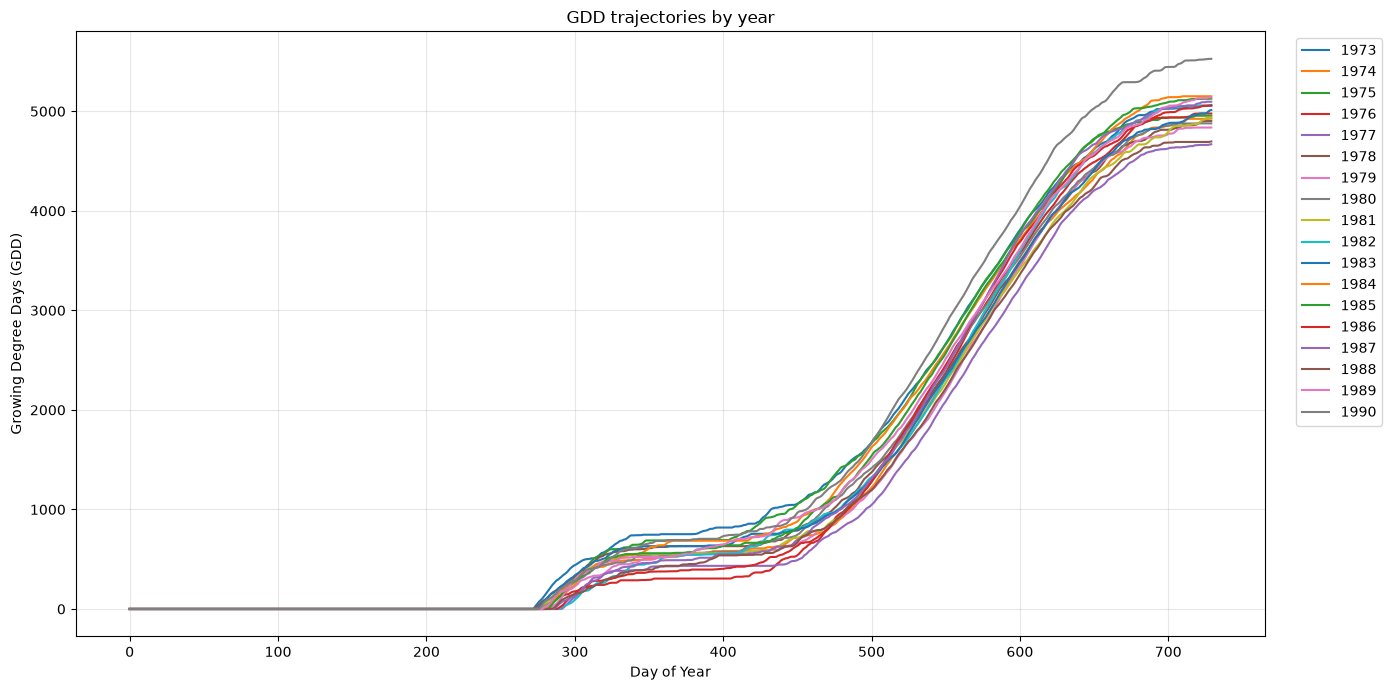

In [31]:
years = range(1973, 1991)  # 18 years

plt.figure(figsize=(14, 7))

for i, year in enumerate(years):
    plt.plot(
        np.arange(gdd_all.shape[1]),
        gdd_all[i],
        label=str(year)
    )

plt.xlabel('Day of Year')
plt.ylabel('Growing Degree Days (GDD)')
plt.title('GDD trajectories by year')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
fint_all = df_("frac_intercepted")
gdd_all = sf("tsum")  # thermal time since emergence, torchcrop's analogue of SIMPLACE TSUM

# Unit bridge torchcrop -> FraNchEstYN. torchcrop's biomass states (wlv, wst,
# wso, ...) are documented as g m-2 (torchcrop/states/model_state.py); the
# external crop-model contract FraNchEstYN reads (CropModelData.agb/.yield_ in
# simpest/models/fr_data.py) is documented in kg ha-1. torchcrop is a
# third-party package we don't modify, so the conversion is applied here, at
# the boundary, instead. 1 g/m2 = 10 kg/ha.
G_M2_TO_KG_HA = 10.0
agb_all_kgha = agb_all * G_M2_TO_KG_HA
yield_all_kgha = yield_all * G_M2_TO_KG_HA

rows = []
for b, s in enumerate(seasons):
    d_all = pd.DatetimeIndex(dates_batch[b])
    sow_hit = np.where((d_all.dayofyear == s["isow"]) & (d_all.year == s["year"]))[0][0]
    maturity_hit = np.where(dvs_all[b] >= 2.0)[0][0]
    d = d_all[sow_hit : maturity_hit + 1]
    rows.append(
        pd.DataFrame(
            {
                "year": d.year,
                "doy": d.dayofyear,
                "agb": agb_all_kgha[b, sow_hit : maturity_hit + 1],
                "yield": yield_all_kgha[b, sow_hit : maturity_hit + 1],
                "fint": fint_all[b, sow_hit : maturity_hit + 1],
                "gdd": gdd_all[b, sow_hit : maturity_hit + 1],
                "dvs": dvs_all[b, sow_hit : maturity_hit + 1],
                "season": s["year"],
            }
        )
    )

crop_model_df = pd.concat(rows, ignore_index=True).sort_values(["year", "doy"]).reset_index(drop=True)
print(crop_model_df.shape)
print(crop_model_df.groupby("season")["doy"].count().rename("days_in_cycle"))
crop_model_df.tail()

(4651, 8)
season
1973    251
1974    266
1975    249
1976    261
1977    265
1978    266
1979    268
1980    262
1981    269
1982    256
1983    266
1984    247
1985    249
1986    251
1987    258
1988    265
1989    258
1990    244
Name: days_in_cycle, dtype: int64


,year,doy,agb,yield,fint,gdd,dvs,season
4646,1991,148,10566.517578,6589.022949,0.296863,1950.242554,1.900243,1990
4647,1991,149,10590.671875,6613.177734,0.285637,1975.832031,1.925833,1990
4648,1991,150,10611.547852,6634.053223,0.274957,2001.684570,1.951685,1990
4649,1991,151,10630.660156,6653.166504,0.264516,2027.668091,1.977669,1990
4650,1991,152,10645.389648,6667.895020,0.254358,2052.789062,2.000000,1990


In [ ]:
crop_model_df

## 6. Run FraNchEstYN (septoria disease model) on the torchcrop-derived crop trajectory

Reuse the existing Indiana weather/management/reference inputs from `1_Run Simpest.ipynb` (`data/New/`). Crop growth itself comes entirely from the torchcrop-derived `crop_model_df` (FraNchEstYN's external crop-model branch), so only the **disease** parameters are calibrated here, freely, against the reference septoria severity — no pre-calibrated FraNchEstYN parameter values are injected. `FRANCH_USE_GDD = True` is required here — the crop-model series now comes from torchcrop (an internal Python model), and calendar-day cycle interpolation would run out of step with the thermal-time-driven epidemic (see the disease-severity validation notes).

In [6]:
ref_df = read_df(path_reference_f)

fr_cfg = franchestyn.FranchestynConfig(
    crop_type=FRANCH_CROP_TYPE,
    disease_type=FRANCH_DISEASE_TYPE,
    fungicide_type=None,
    site=FRANCH_SITE,
    variety=FRANCH_VARIETY,
    disease=FRANCH_DISEASE,
    is_calibration=True,
    calibration_variable="disease",
    use_gdd=FRANCH_USE_GDD,
    use_prev_day_alignment=True,
    n_restarts=3,
    max_iter=100,
)

# Damage-coefficient params excluded from calibration (cannot be identified from severity data alone)
disease_disable = {
    "RUEreducerDamage", "LightStealerDamage",
    "SenescenceAcceleratorDamage", "AssimilateSappersDamage",
}
fr_cfg.disease_parameters = franchestyn.deactivate_calibration(
    fr_cfg.disease_parameters, disease_disable
)

# Widen upper bounds — calibration previously hit the ceiling on both params
fr_cfg.disease_parameters["OuterInoculumMax"]["max"] = 1.0
fr_cfg.disease_parameters["PathogenSpread"]["max"] = 0.5

# Switch to constant inoculum release (shape 0 instead of default 2).
# Shape 2 (logistic decrease) cuts external inoculum to near-zero by cycle 70–75%
# (mid-May for Indiana) — exactly when septoria is most active. Shape 0 keeps
# primary inoculum available throughout, letting internal spread calibrate freely.
fr_cfg.disease_parameters["OuterInoculumShapeRelease"]["value"] = 0

print(f"FraNchEstYN configured: calibration_variable=disease, n_restarts=3, max_iter=100")
print(f"  OuterInoculumMax       bounds: {fr_cfg.disease_parameters['OuterInoculumMax']['min']} – {fr_cfg.disease_parameters['OuterInoculumMax']['max']}")
print(f"  PathogenSpread         bounds: {fr_cfg.disease_parameters['PathogenSpread']['min']} – {fr_cfg.disease_parameters['PathogenSpread']['max']}")
print(f"  OuterInoculumShapeRelease value: {fr_cfg.disease_parameters['OuterInoculumShapeRelease']['value']}  (0=constant)")


FraNchEstYN configured: calibration_variable=disease, n_restarts=3, max_iter=100
  OuterInoculumMax       bounds: 0.01 – 1.0
  PathogenSpread         bounds: 0.001 – 0.5
  OuterInoculumShapeRelease value: 0  (0=constant)


In [7]:
result = franchestyn.run_franchestyn(
    weather_df=weather_df,
    management_df=management_df,
    crop_model_df=crop_model_df,
    ref_df=ref_df,
    start_year=FRANCH_START_YEAR,
    end_year=FRANCH_END_YEAR,
    config=fr_cfg,
)

summary = result["outputs"]["summary"]
simulation_df = pd.DataFrame(result["outputs"]["simulation"])
simulation_df["Date"] = pd.to_datetime(simulation_df["Date"], dayfirst=True)

# Note: FraNchEstYN internally stores disease severity as 0-1 (tissue fraction)
# build_season_summary expects 0-1 and multiplies by 100 internally for AUDPC
season_summary = franchestyn.build_season_summary(simulation_df, site=fr_cfg.site, variety=fr_cfg.variety)

# Convert disease severity to percentage (0-100) for direct comparison with reference data
# After summary is built, so AUDPC calculation remains correct
simulation_df["DiseaseSeverity"] = simulation_df["DiseaseSeverity"] * 100.0
season_summary["DiseaseSeverity"] = season_summary["DiseaseSeverity"] * 100.0

print("FraNchEstYN completed")
print("RMSE (disease severity vs reference):", summary.get("rmse"))
print(f"{len(season_summary)} growing seasons summarised")

- Calibrating 16 using multi-start simplex method.
- Parameters:
['disease_OuterInoculumMax', 'disease_PathogenSpread', 'disease_WetnessDurationOptimum', 'disease_WetnessDurationMinimum', 'disease_DryCriticalInterruption', 'disease_Tmin', 'disease_Topt', 'disease_Tmax', 'disease_RelativeHumidityCritical', 'disease_Rain50Detachment', 'disease_RelativeHumidityNotLimiting', 'disease_HydroThermalTimeOnset', 'disease_CyclePercentageOnset', 'disease_LatencyDuration', 'disease_SporulationDuration', 'disease_OuterInoculumShapeParameter']
Run 3/3 Iteration 100/100 CURR RMSE=20.5260
Best RMSE: 16.4620
{'disease_OuterInoculumMax': np.float64(0.4362516947946663), 'disease_PathogenSpread': np.float64(0.3029976278710954), 'disease_WetnessDurationOptimum': np.float64(44.12130703492163), 'disease_WetnessDurationMinimum': np.float64(13.437616894017857), 'disease_DryCriticalInterruption': np.float64(16.291223625526392), 'disease_Tmin': np.float64(6.0818586044226866), 'disease_Topt': np.float64(21.806559

## 7. Visualize combined crop + disease results

First, one representative season: attainable vs disease-actual above-ground biomass from the torchcrop-driven crop model, together with the simulated septoria severity that FraNchEstYN layers on top of it.

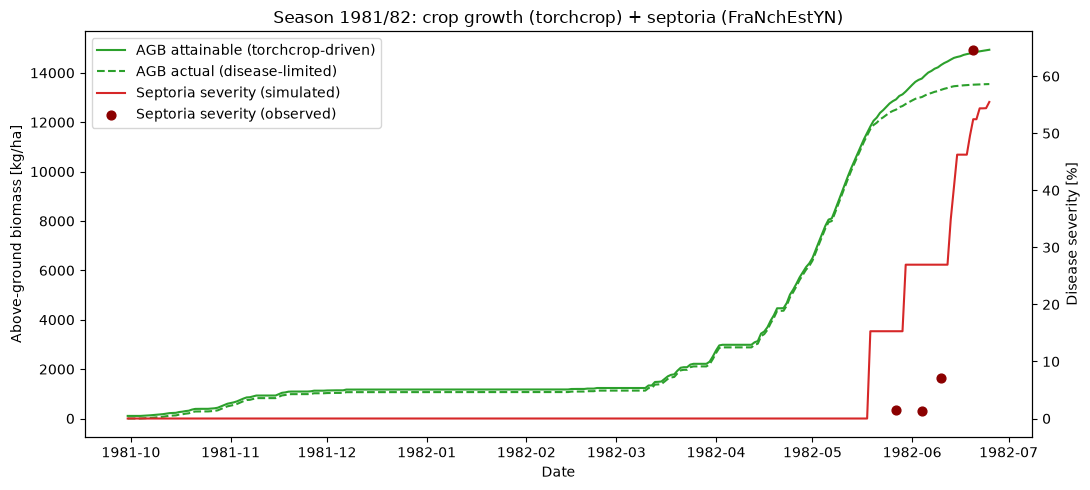

In [8]:
PLOT_SEASON = 1981  # sowing year; disease occurs in spring of PLOT_SEASON+1

sub = simulation_df[simulation_df["GrowingSeason"] == PLOT_SEASON]
harvest_yr = PLOT_SEASON + 1

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(sub["Date"], sub["AGBattainable"], color="tab:green", label="AGB attainable (torchcrop-driven)")
ax1.plot(sub["Date"], sub["AGBactual"], color="tab:green", ls="--", label="AGB actual (disease-limited)")
ax1.set_ylabel("Above-ground biomass [kg/ha]")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(sub["Date"], sub["DiseaseSeverity"], color="tab:red", label="Septoria severity (simulated)")

# Overlay reference observations for the harvest year
ref_season = ref_df[(ref_df["thisDisease"].notna()) & (ref_df["year"] == harvest_yr)]
if not ref_season.empty:
    ref_dates = pd.Timestamp(year=harvest_yr, month=1, day=1) + pd.to_timedelta(ref_season["DOY"] - 1, unit="D")
    ax2.scatter(ref_dates, ref_season["thisDisease"], color="darkred", s=40, zorder=5, label="Septoria severity (observed)")

ax2.set_ylabel("Disease severity [%]")
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title(f"Season {PLOT_SEASON}/{str(harvest_yr)[2:]}: crop growth (torchcrop) + septoria (FraNchEstYN)")
fig.tight_layout()
plt.show()


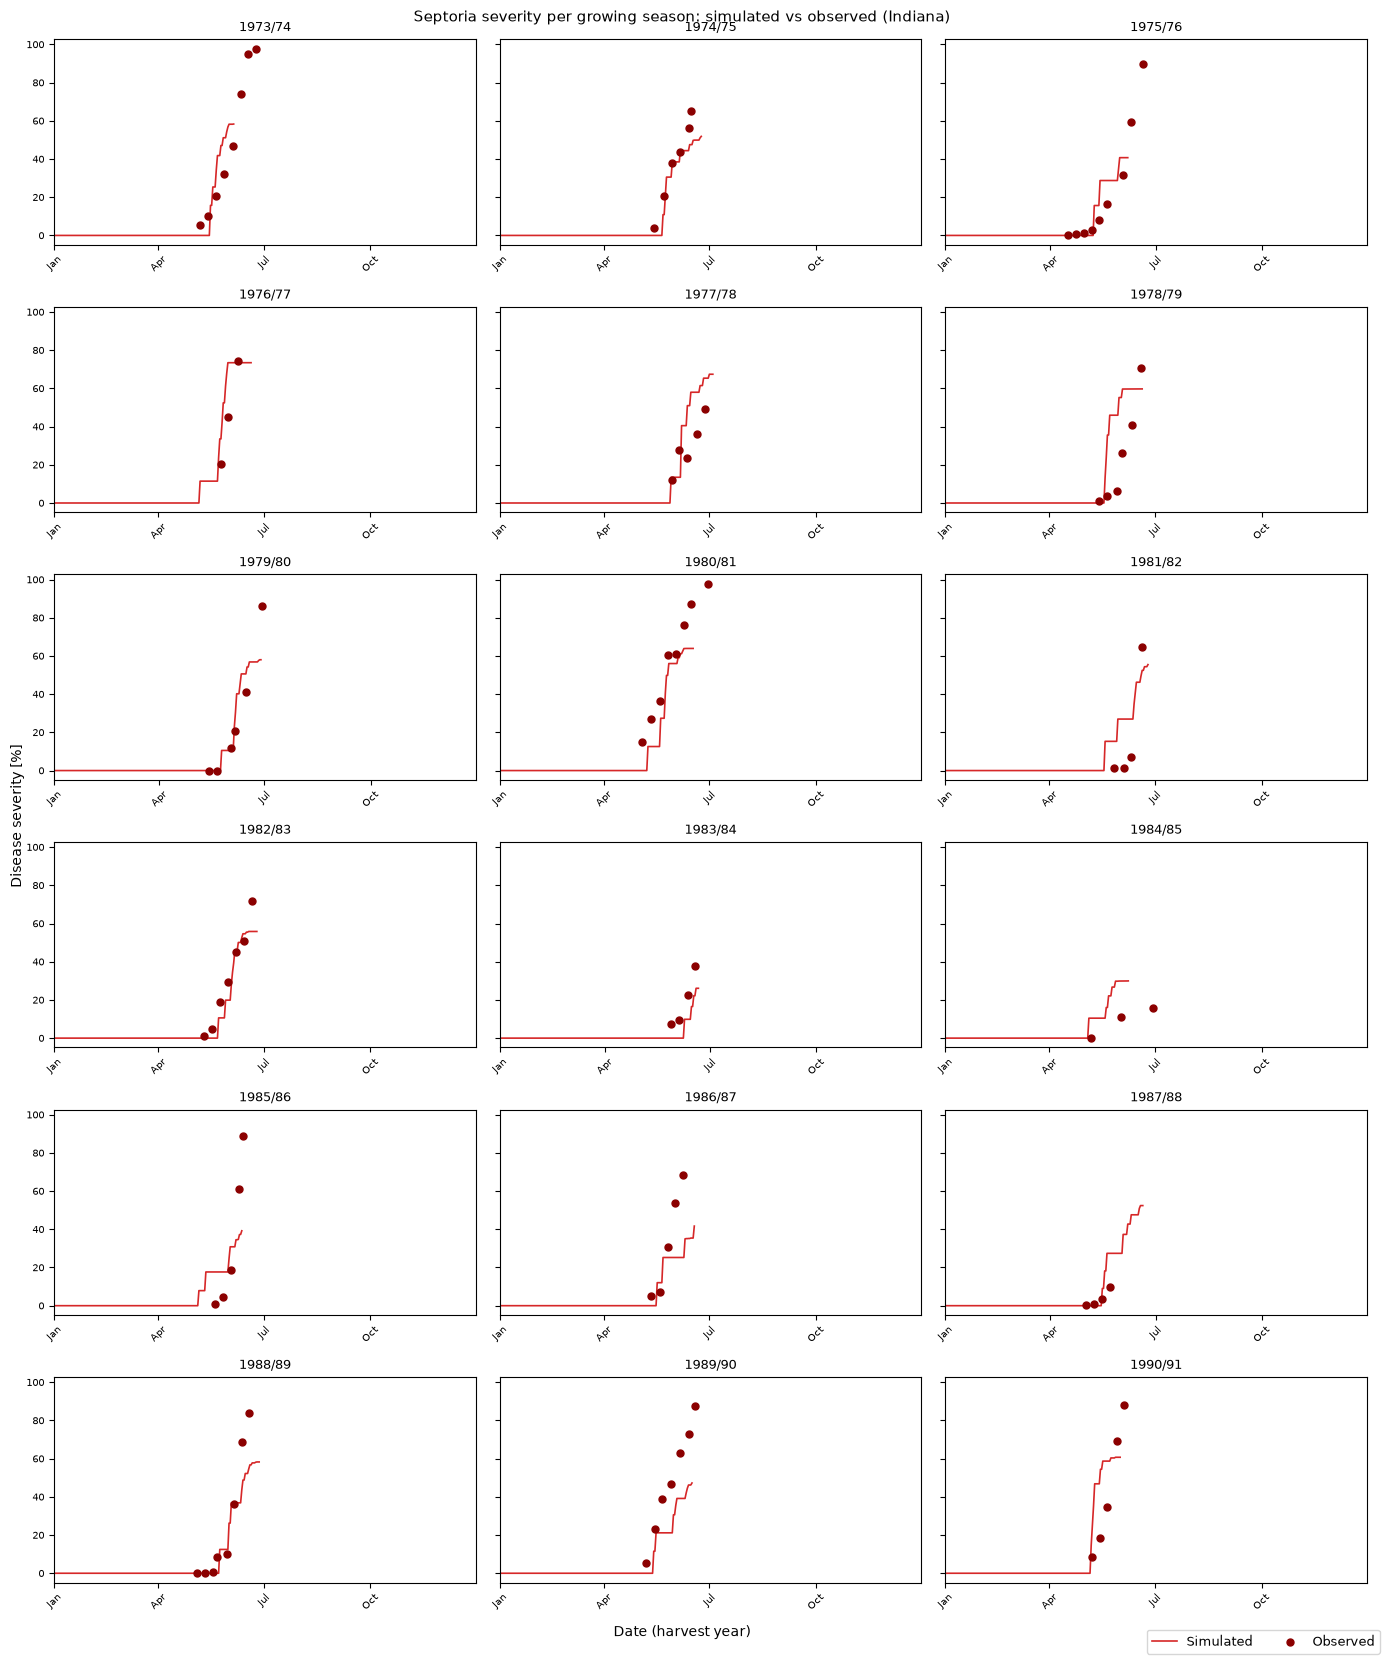

In [9]:

sim_years = sorted(simulation_df["GrowingSeason"].unique())
ref_dis = ref_df[ref_df["thisDisease"].notna()].copy()

n_cols = 3
n_rows = (len(sim_years) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.8), sharey=True)
axes_flat = axes.flatten()

for i, yr in enumerate(sim_years):
    ax = axes_flat[i]
    sub = simulation_df[simulation_df["GrowingSeason"] == yr]

    # Management uses sowing year; disease peaks in the following calendar year (harvest year)
    harvest_yr = yr + 1
    ax.plot(sub["Date"], sub["DiseaseSeverity"], color="tab:red", lw=1.2, label="Simulated")

    # Reference uses harvest year — match to harvest_yr, not sowing year
    ref_yr = ref_dis[ref_dis["year"] == harvest_yr]
    if not ref_yr.empty:
        ref_dates = pd.Timestamp(year=harvest_yr, month=1, day=1) + pd.to_timedelta(ref_yr["DOY"] - 1, unit="D")
        ax.scatter(ref_dates, ref_yr["thisDisease"], color="darkred", s=25, zorder=5, label="Observed")

    ax.set_title(f"{yr}/{str(harvest_yr)[2:]}", fontsize=9)
    ax.set_xlim(pd.Timestamp(f"{harvest_yr}-01-01"), pd.Timestamp(f"{harvest_yr}-12-31"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=9, ncol=2)
fig.supxlabel("Date (harvest year)", fontsize=10)
fig.supylabel("Disease severity [%]", fontsize=10)
fig.suptitle("Septoria severity per growing season: simulated vs observed (Indiana)", fontsize=11)
fig.tight_layout()
plt.show()


In [10]:
ref_dis['thisDisease'].describe()

count    111.000000
mean      34.513979
std       30.245761
min        0.000000
25%        7.333975
50%       27.548539
75%       59.914284
max       97.770395
Name: thisDisease, dtype: float64

In [11]:
simulation_df["DiseaseSeverity"].describe()

count    4651.000000
mean        4.694949
std        13.929579
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        73.455428
Name: DiseaseSeverity, dtype: float64

In [12]:
# Diagnostic: fint trajectory from torchcrop for season 1990 (harvest 1991, worst miss)
s90_crop = crop_model_df[crop_model_df["season"] == 1990].copy()
s90_crop["date"] = pd.to_datetime(
    s90_crop["year"].astype(str) + s90_crop["doy"].astype(str).str.zfill(3), format="%Y%j"
)
print(f"1990 season: {len(s90_crop)} days, sowing {s90_crop['date'].iloc[0].date()} → maturity {s90_crop['date'].iloc[-1].date()}")
print(f"  fint  max={s90_crop['fint'].max():.3f}  at {s90_crop.loc[s90_crop['fint'].idxmax(), 'date'].date()}")
print(f"  gdd   max={s90_crop['gdd'].max():.1f}")
print(f"  yield >0 first at {s90_crop[s90_crop['yield']>0]['date'].iloc[0].date() if (s90_crop['yield']>0).any() else 'never'}")

# Monthly fint profile
s90_crop["month"] = s90_crop["date"].dt.month
print("\nMonthly mean fint (1990 sowing season):")
print(s90_crop.groupby(["year","month"])["fint"].max().rename("fint_max").to_string())

# Inoculum shape analysis with current calibrated params
import math
pct_first = 34.4  # calibrated CyclePercentageOnset
slope     = 0.75  # calibrated OuterInoculumShapeParameter
ino_max_pct = pct_first + (100.0 - pct_first) / 2.0
print(f"\n=== OuterInoculumShapeRelease=2 logistic decline (ino_max_pct={ino_max_pct:.1f}%) ===")
for c in [34, 40, 50, 60, 67, 70, 75, 80]:
    ino_dec = 1.0 / (1.0 + math.exp(slope * (c - ino_max_pct)))
    print(f"  cycle {c:3d}%  inoculum = {ino_dec:.4f}  (shape=0 constant would be 1.0000)")


1990 season: 244 days, sowing 1990-10-01 → maturity 1991-06-01
  fint  max=0.842  at 1991-04-02
  gdd   max=2052.8
  yield >0 first at 1991-04-03

Monthly mean fint (1990 sowing season):
year  month
1990  10       0.524773
      11       0.784902
      12       0.800783
1991  1        0.801107
      2        0.815514
      3        0.842425
      4        0.842455
      5        0.618586
      6        0.254358

=== OuterInoculumShapeRelease=2 logistic decline (ino_max_pct=67.2%) ===
  cycle  34%  inoculum = 1.0000  (shape=0 constant would be 1.0000)
  cycle  40%  inoculum = 1.0000  (shape=0 constant would be 1.0000)
  cycle  50%  inoculum = 1.0000  (shape=0 constant would be 1.0000)
  cycle  60%  inoculum = 0.9955  (shape=0 constant would be 1.0000)
  cycle  67%  inoculum = 0.5374  (shape=0 constant would be 1.0000)
  cycle  70%  inoculum = 0.1091  (shape=0 constant would be 1.0000)
  cycle  75%  inoculum = 0.0029  (shape=0 constant would be 1.0000)
  cycle  80%  inoculum = 0.0001  (s

Now the season summary across the full 1973–1990 Indiana rotation: the epidemic pressure (AUDPC, area under the disease-progress curve) and the resulting yield loss each year.

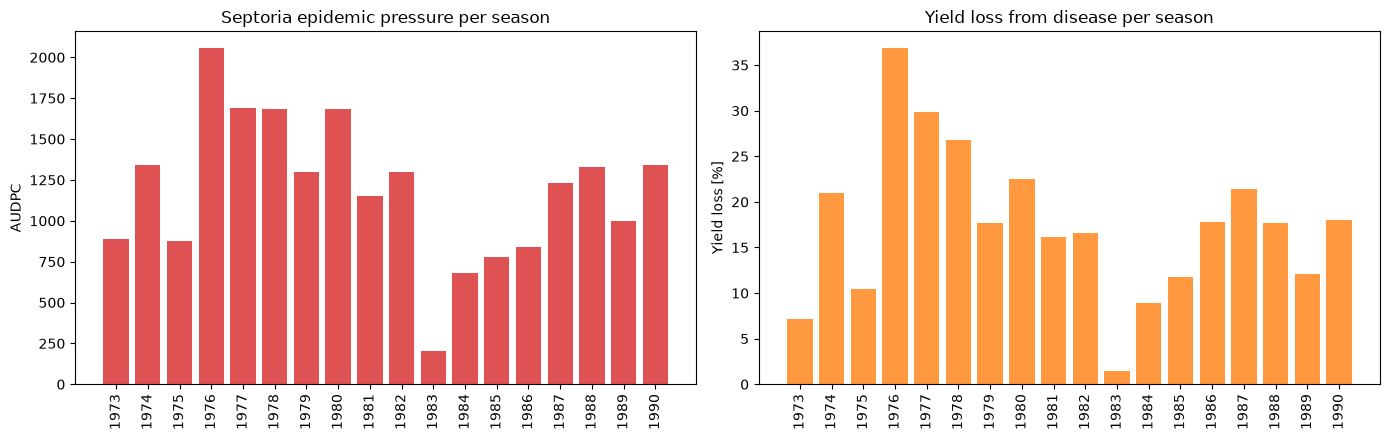

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(season_summary["GrowingSeason"].astype(str), season_summary["AUDPC"], color="tab:red", alpha=0.8)
axes[0].set_title("Septoria epidemic pressure per season")
axes[0].set_ylabel("AUDPC")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(season_summary["GrowingSeason"].astype(str), season_summary["YieldLossPerc"], color="tab:orange", alpha=0.8)
axes[1].set_title("Yield loss from disease per season")
axes[1].set_ylabel("Yield loss [%]")
axes[1].tick_params(axis="x", rotation=90)

fig.tight_layout()
plt.show()